In [82]:
# ==============================================================================
# 1: VARIABLE DEFINITIONS
# ==============================================================================
 
# SoVI 2014
sovi_vars_2014 = [
    'MEDAGE', 'PERCAP', 'PPUNIT', 'QAGEDEP', 'QASIAN', 'QBLACK', 'QCVLUN', 'QED12LES',
    'QESL', 'QEXTRCT', 'QFEMALE', 'QFEMLBR', 'QFHH', 'QHISP', 'QHSEBRDN', 'QMOHO', 'QNATAM',
    'QNOAUTO', 'QUNINSUR', 'QPOVTY', 'QRENTER', 'QRICH200K', 'QSERV', 'QUNOCCHU', 'QSSBEN',
    'QFAM', 'MDHSEVAL', 'MDGRENT'
]
# SoVI 2019 - Removes MDHSEVAL, MDGRENT; replaces QFAM with QSNGPKIDS, adds QDISABL
sovi_vars_2019 = [
    'MEDAGE', 'PERCAP', 'PPUNIT', 'QAGEDEP', 'QASIAN', 'QBLACK', 'QCVLUN', 'QED12LES',
    'QESL', 'QEXTRCT', 'QFEMALE', 'QFEMLBR', 'QFHH', 'QHISP', 'QHSEBRDN', 'QMOHO', 'QNATAM',
    'QNOAUTO', 'QUNINSUR', 'QPOVTY', 'QRENTER', 'QRICH200K', 'QSERV', 'QUNOCCHU', 'QSSBEN',
    'QDISABLE', 'QSNGPKIDS'
]
# 2014 and 2019 combined - QFAM and QSNGPKIDS are inverses of each other, so choose either
sovi_vars_com = [
    'MEDAGE', 'PERCAP', 'PPUNIT', 'QAGEDEP', 'QASIAN', 'QBLACK', 'QCVLUN', 'QED12LES',
    'QESL', 'QEXTRCT', 'QFEMALE', 'QFEMLBR', 'QFHH', 'QHISP', 'QHSEBRDN', 'QMOHO', 'QNATAM',
    'QNOAUTO', 'QUNINSUR', 'QPOVTY', 'QRENTER', 'QRICH200K', 'QSERV', 'QUNOCCHU', 'QSSBEN',
    'QDISABLE', 'QSNGPKIDS', 'MDHSEVAL', 'MDGRENT'
]
 
# CHOOSE WHICH ONE:
sovi_vars_base = sovi_vars_2019

In [83]:
# ==============================================================================
# 2: DATA PREP AND CLEANING
# ==============================================================================
 
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
 
# STANDARD SOVI PROCEDURE FOR ANY STATE'S CENSUS TRACTS
 
# 2.1. Load and coerce
df_initial = pd.read_csv('../data/SoVI-vars-nationwide_2019.csv')
for col in sovi_vars_base:
    df_initial[col] = pd.to_numeric(df_initial[col], errors='coerce')
df_initial[sovi_vars_base] = df_initial[sovi_vars_base].mask(df_initial[sovi_vars_base] < 0, np.nan)
 
# 2.2. Choose state (comment out to use all CONUS tracts)
exclude_states = ['Alaska', 'Hawaii']
df_initial = df_initial[~df_initial['State Name'].isin(exclude_states)]
state = 'Arkansas'
#county = 'Shelby '
df_initial = df_initial[df_initial['State Name'] == state]
#df_initial = df_initial[df_initial['County Name'] == county]
 
 
# 2.3. Filter low-population tracts
pop_threshold, hhold_threshold = 50, 50
pop_mask = (df_initial['TOTALPOP'] > pop_threshold) & (df_initial['TOTALHHOLD'] > hhold_threshold)
num_dropped = len(df_initial) - pop_mask.sum()
df_initial = df_initial[pop_mask]
print(f"Dropped {num_dropped} tracts with low population/households.")
 
# 2.4. FIX: Impute FIRST on raw data, THEN scale.
#      V2 scaled before imputing, which meant NaNs influenced the mean/std fit
#      and KNN neighbors were selected in an already-distorted space.
 
print(df_initial)

# Step A: KNN imputation in raw variable units
num_missing = df_initial[sovi_vars_base].isnull().sum().sum()
imputer = KNNImputer(n_neighbors=5)
df_imputed_raw = pd.DataFrame(
    imputer.fit_transform(df_initial[sovi_vars_base]),
    columns=sovi_vars_base,
    index=df_initial.index
)
print(f"Total values imputed: {num_missing}")
 
# Step B: Z-score scaling on fully-imputed data
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_imputed_raw),
    columns=sovi_vars_base,
    index=df_initial.index
)
 

Dropped 3 tracts with low population/households.
           GEOID State Name County Name  Year  TOTALPOP  TOTALHHOLD  QAGEDEP  \
2874  5001480100   Arkansas   Arkansas   2019      1428         610   0.2584   
2875  5001480200   Arkansas   Arkansas   2019      1450         619   0.2228   
2876  5001480300   Arkansas   Arkansas   2019      2950        1114   0.2481   
2877  5001480400   Arkansas   Arkansas   2019      2296        1044   0.2657   
2878  5001480500   Arkansas   Arkansas   2019      3772        1572   0.2603   
...          ...        ...         ...   ...       ...         ...      ...   
3555  5149952302   Arkansas       Yell   2019      2926        1073   0.2652   
3556  5149952401   Arkansas       Yell   2019      2927        1028   0.2310   
3557  5149952402   Arkansas       Yell   2019      5461        1706   0.2174   
3558  5149952500   Arkansas       Yell   2019      4329        1569   0.2964   
3559  5149952600   Arkansas       Yell   2019      2637        1037   0

Kaiser criterion: 5 components retained


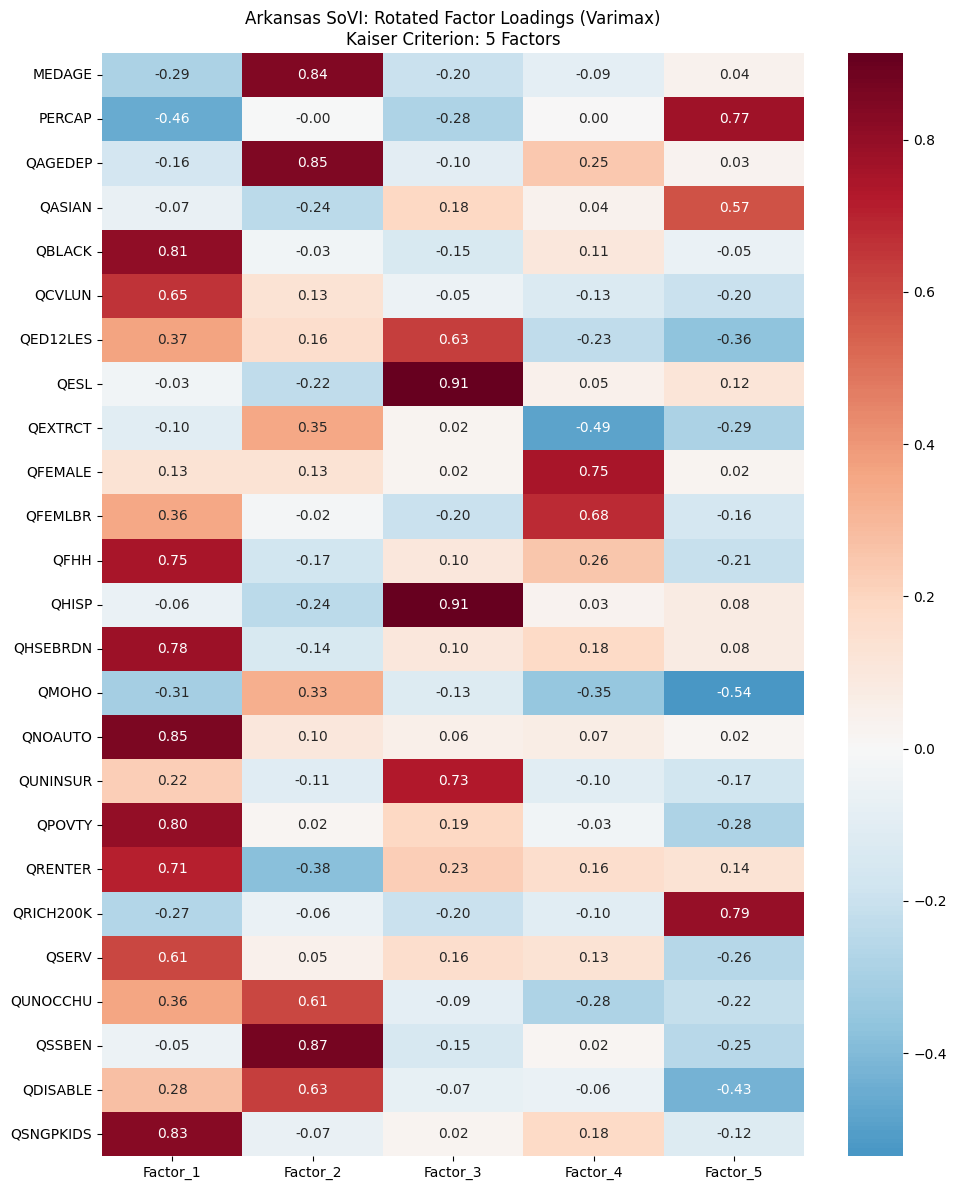

In [84]:
# ==============================================================================
# CELL 3: PCA + VARIMAX
# ==============================================================================
 
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from factor_analyzer.rotator import Rotator
 
# FIX: vars_to_drop is applied locally here so this cell is self-contained.
#      In V2, dropping vars mutated the global sovi_vars list, requiring a
#      re-run of the data prep cell to reset it. Now we derive a clean working
#      list each time this cell runs without touching sovi_vars_base.
vars_to_drop = ['QNATAM', 'PPUNIT']
sovi_vars = [v for v in sovi_vars_base if v not in vars_to_drop]
 
# Work from the scaled data
df_pca_input = df_scaled[sovi_vars]
 
# 3.1. Initial PCA to determine number of components (Kaiser criterion: eigenvalue > 1)
pca_init = PCA()
pca_init.fit(df_pca_input)
eigenvalues = pca_init.explained_variance_
n_comp = len(eigenvalues[eigenvalues > 1])
print(f"Kaiser criterion: {n_comp} components retained")
 
# 3.2. Extract unrotated loadings
pca_final = PCA(n_components=n_comp)
pca_final.fit(df_pca_input)
unrotated_loadings = pca_final.components_.T * np.sqrt(pca_final.explained_variance_)
 
# 3.3. Varimax rotation
rotator = Rotator(method='varimax')
rotated_loadings = rotator.fit_transform(unrotated_loadings)
 
loadings_rotated = pd.DataFrame(
    rotated_loadings,
    columns=[f'Factor_{i+1}' for i in range(n_comp)],
    index=sovi_vars
)
 
# 3.4. Heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(loadings_rotated, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title(f'{state} SoVI: Rotated Factor Loadings (Varimax)\nKaiser Criterion: {n_comp} Factors')
plt.tight_layout()
plt.show()

In [85]:
# ==============================================================================
# 4: CALCULATE SoVI SCORES
# ==============================================================================
 
from scipy.stats.mstats import winsorize
 
# 4.1. Factor score coefficients
#      FIX (V2): V2 used pinv(loadings) which bypasses the correlation structure.
#      Correct method: R⁻¹ × L where R is the correlation matrix of the scaled data.
#      Using np.linalg.inv explicitly; falls back to pinv if R is near-singular.
R = df_pca_input.corr().values
try:
    R_inv = np.linalg.inv(R)
except np.linalg.LinAlgError:
    print("Warning: correlation matrix is singular; falling back to pseudoinverse.")
    R_inv = np.linalg.pinv(R)
weights = R_inv.dot(rotated_loadings)
 
# 4.2. Factor scores for every tract
factor_scores = pd.DataFrame(
    df_pca_input.values.dot(weights),
    columns=[f'Factor_{i+1}' for i in range(n_comp)],
    index=df_initial.index
)
 
# 4.3. FIX: Auto-detect which factors need inversion.
#      A factor should be inverted if its dominant loading comes from a
#      positively-valenced variable (i.e., higher = less vulnerable).
#      V2 hardcoded factor numbers, which breaks if factor order shifts.
POSITIVE_ANCHORS = {'PERCAP', 'QRICH200K'}
 
factors_to_invert = []
for col in factor_scores.columns:
    factor_loadings = loadings_rotated[col].abs()
    dominant_var = factor_loadings.idxmax()
    dominant_loading_sign = loadings_rotated.loc[dominant_var, col]
    if dominant_var in POSITIVE_ANCHORS and dominant_loading_sign > 0:
        factors_to_invert.append(col)
    # Also invert if a positive anchor has the largest absolute loading
    # AND its loading is negative (factor already points toward vulnerability —
    # but dominant var is negative anchor — leave it alone)
 
print(f"Auto-detected factors to invert: {factors_to_invert}")
print("(Review against heatmap — override manually below if needed)\n")
 
# Optional manual override — uncomment and set if auto-detection is wrong:
#factors_to_invert = ['Factor_3']
 
# 4.4. Apply inversions
#      FIX (V2): The if-block was outside the for-loop due to wrong indentation,
#      so only the last factor in the list was ever actually inverted.
factor_scores_adjusted = factor_scores.copy()
for col in factors_to_invert:
    if col in factor_scores_adjusted.columns:
        factor_scores_adjusted[col] = factor_scores_adjusted[col] * -1
        print(f"Inverted: {col}")
 
# 4.5. FIX: Winsorize each factor individually BEFORE summing.
#      V2 winsorized the composite score, which meant the factor columns in df_final
#      were inconsistent with the reported SoVI_Score at the tails.
for col in factor_scores_adjusted.columns:
    factor_scores_adjusted[col] = winsorize(
        factor_scores_adjusted[col], limits=[0.01, 0.01]
    )
 
# 4.6. Final SoVI score = sum of (winsorized, inverted) factors
df_initial['SoVI_Score'] = factor_scores_adjusted.sum(axis=1)
 
# Merge factor scores into main dataframe
df_final = pd.concat([df_initial, factor_scores_adjusted], axis=1)
print("\nFinal SoVI calculation complete!\n")
 
# Variance summary
var_exp = pca_init.explained_variance_ratio_
cum_var_exp = np.cumsum(var_exp)
print(f"{'Factor':<10} | {'Expl. Var (%)':<15} | {'Cumul. Var (%)'}")
print("-" * 45)
for i in range(n_comp):
    print(f"Factor {i+1:<3} | {var_exp[i]*100:<15.2f}% | {cum_var_exp[i]*100:.2f}%")
 
print("")
print(df_final.head())
 
df_final.to_csv(f'../results/SoVI-{state}_2019.csv')

Auto-detected factors to invert: ['Factor_5']
(Review against heatmap — override manually below if needed)

Inverted: Factor_5

Final SoVI calculation complete!

Factor     | Expl. Var (%)   | Cumul. Var (%)
---------------------------------------------
Factor 1   | 28.75          % | 28.75%
Factor 2   | 19.18          % | 47.93%
Factor 3   | 11.55          % | 59.48%
Factor 4   | 5.70           % | 65.18%
Factor 5   | 4.55           % | 69.73%

           GEOID State Name County Name  Year  TOTALPOP  TOTALHHOLD  QAGEDEP  \
2874  5001480100   Arkansas   Arkansas   2019      1428         610   0.2584   
2875  5001480200   Arkansas   Arkansas   2019      1450         619   0.2228   
2876  5001480300   Arkansas   Arkansas   2019      2950        1114   0.2481   
2877  5001480400   Arkansas   Arkansas   2019      2296        1044   0.2657   
2878  5001480500   Arkansas   Arkansas   2019      3772        1572   0.2603   

      QFEMALE  MEDAGE  QBLACK  ...  QDISABLE  QUNOCCHU  MDGRENT MDHSE

In [86]:
# ==============================================================================
# CELL 4B: VARIANCE-WEIGHTED SoVI SCORE
# Standard SoVI sums factors equally. This version weights each factor by its
# share of total explained variance before summing, so factors that capture
# more of the data structure contribute proportionally more to the final score.
# ==============================================================================

# 4B.1. Get explained variance ratios for the retained components only
#       (pca_init has all components; slice to n_comp)
retained_var = pca_init.explained_variance_ratio_[:n_comp]
weights_ev = retained_var / retained_var.sum()  # normalize to sum to 1

print("Explained variance weights per factor:")
for i, (w, v) in enumerate(zip(weights_ev, retained_var)):
    print(f"  Factor_{i+1}: {v*100:.2f}% explained  →  weight {w:.4f}")

# 4B.2. Apply weights to the already-inverted, already-winsorized factor scores
#       (factor_scores_adjusted already has inversions and winsorization from Cell 4)
factor_scores_weighted = factor_scores_adjusted * weights_ev

# 4B.3. Weighted SoVI score
df_final['SoVI_Score_Weighted'] = factor_scores_weighted.sum(axis=1)

# 4B.4. Quick comparison of the two scores
print("\nScore comparison (unweighted vs weighted):")
print(df_final[['SoVI_Score', 'SoVI_Score_Weighted']].describe().round(4))

# Correlation between the two — high correlation means weighting doesn't change
# the relative ranking much; low correlation means it matters significantly
corr = df_final['SoVI_Score'].corr(df_final['SoVI_Score_Weighted'])
print(f"\nPearson correlation between scores: {corr:.4f}")

# 4B.5. Export — both scores in the same file
df_final.to_csv(f'../results/SoVI-{state}_2019.csv', index=False)
print("\nExported with both SoVI_Score and SoVI_Score_Weighted.")

Explained variance weights per factor:
  Factor_1: 28.75% explained  →  weight 0.4123
  Factor_2: 19.18% explained  →  weight 0.2750
  Factor_3: 11.55% explained  →  weight 0.1656
  Factor_4: 5.70% explained  →  weight 0.0818
  Factor_5: 4.55% explained  →  weight 0.0652

Score comparison (unweighted vs weighted):
       SoVI_Score  SoVI_Score_Weighted
count    683.0000             683.0000
mean       0.0019              -0.0021
std        2.1365               0.5224
min       -7.6833              -1.3745
25%       -1.2478              -0.3863
50%        0.1034              -0.0431
75%        1.4356               0.3148
max        6.2707               1.6459

Pearson correlation between scores: 0.8440

Exported with both SoVI_Score and SoVI_Score_Weighted.


In [87]:
# ==============================================================================
# 5: SPATIAL JOIN + EXPORT
# ==============================================================================
 
import geopandas as gpd
 
shapefile_path = '/Users/maxbdixon/Documents/QGIS/cb_2019_us_tract_500k/cb_2019_us_tract_500k.shp'
gdf = gpd.read_file(shapefile_path)
gdf['GEOID'] = gdf['GEOID'].astype(str).str.zfill(11)
gdf = gdf.set_index("GEOID")
 
results_indexed = df_final.copy()
geoids = df_initial['GEOID'].astype(str).str.zfill(11)
if 'GEOID' in results_indexed.columns:
    results_indexed = results_indexed.drop(columns=['GEOID'])
results_indexed.index = geoids
 
gdf_final = gdf[['geometry']].join(results_indexed, how='inner')
 
unique_states = gdf_final.index.str[:2].unique()
print(f"Success! Joined data contains {len(gdf_final)} tracts across State FIPS: {list(unique_states)}")
 
if not gdf_final.empty:
    output_file = f'../results/SoVI_2019_{state}.gpkg'
    gdf_final.reset_index().to_file(output_file, driver="GPKG")
    print(f"Saved to: {output_file}")
else:
    print("Join failed. No matching GEOIDs found.")

Success! Joined data contains 683 tracts across State FIPS: ['05']
Saved to: ../results/SoVI_2019_Arkansas.gpkg


In [88]:
# ==============================================================================
# 6: K-MEANS QUALITY CHECKS
# ==============================================================================
 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import cdist, pdist
 
comp_range = range(6, 7)
k_range = range(2, 11)
results = []
 
scaler_km = StandardScaler()
X_full_scaled = scaler_km.fit_transform(factor_scores)
 
print(f"{'Comp':<5} | {'K':<3} | {'Silh (↑)':<8} | {'D-B (↓)':<8} | {'Within (↓)':<10} | {'Inter (↑)'}")
print("-" * 65)
 
for n_comp_km in comp_range:
    X_subset = X_full_scaled[:, :n_comp_km]
    tss_subset = np.sum((X_subset - np.mean(X_subset, axis=0))**2)
 
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        labels = km.fit_predict(X_subset)
        centroids = km.cluster_centers_
 
        pt_to_centroid_dist = np.min(cdist(X_subset, centroids, 'euclidean'), axis=1)
        avg_within_dist = np.mean(pt_to_centroid_dist)
 
        avg_inter_dist = np.mean(pdist(centroids, 'euclidean')) if k > 1 else 0
 
        sil = silhouette_score(X_subset, labels)
        db = davies_bouldin_score(X_subset, labels)
        var_exp_km = (1 - (km.inertia_ / tss_subset)) * 100
 
        results.append({
            'Components': n_comp_km, 'K': k, 'Silhouette': sil,
            'Davies_Bouldin': db, 'Var_Exp_Pct': var_exp_km,
            'Avg_Within_Dist': avg_within_dist, 'Avg_Inter_Dist': avg_inter_dist
        })
        print(f"{n_comp_km:<5} | {k:<3} | {sil:<8.3f} | {db:<8.3f} | {avg_within_dist:<10.3f} | {avg_inter_dist:.3f}")
 
summary_df = pd.DataFrame(results)

Comp  | K   | Silh (↑) | D-B (↓)  | Within (↓) | Inter (↑)
-----------------------------------------------------------------
6     | 2   | 0.217    | 1.716    | 1.855      | 2.135
6     | 3   | 0.253    | 1.468    | 1.724      | 2.932
6     | 4   | 0.236    | 1.420    | 1.563      | 2.809
6     | 5   | 0.229    | 1.264    | 1.454      | 3.048
6     | 6   | 0.241    | 1.155    | 1.373      | 3.108
6     | 7   | 0.232    | 1.219    | 1.320      | 3.093
6     | 8   | 0.205    | 1.273    | 1.266      | 3.026
6     | 9   | 0.185    | 1.350    | 1.238      | 2.973
6     | 10  | 0.197    | 1.256    | 1.208      | 3.090


In [89]:
# ==============================================================================
# CELL 6B: UMAP QUALITY CHECKS ON RAW SCALED VARIABLES (PRE-PCA)
# Bypasses PCA entirely — UMAP reduces directly from the full variable space.
# Compare these metrics to Cell 7 to see if PCA is helping or hurting cluster separation.
# ==============================================================================

import umap

scaler_raw = StandardScaler()
X_scaled_raw = scaler_raw.fit_transform(df_scaled[sovi_vars])

reducer_raw = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_embedded_raw = reducer_raw.fit_transform(X_scaled_raw)

global_mean_raw = np.mean(X_embedded_raw, axis=0)
tss_raw = np.sum((X_embedded_raw - global_mean_raw)**2)

print(f"{'K':<3} | {'Silh (↑)':<7} | {'DB (↓)':<7} | {'Expl %':<8} | {'Within (↓)':<10} | {'Inter (↑)'}")
print("-" * 65)

results_raw = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_embedded_raw)
    centroids = km.cluster_centers_

    sil = silhouette_score(X_embedded_raw, labels)
    db_index = davies_bouldin_score(X_embedded_raw, labels)
    explained_var = (1 - (km.inertia_ / tss_raw)) * 100
    avg_within = np.mean(np.min(cdist(X_embedded_raw, centroids, 'euclidean'), axis=1))
    avg_inter = np.mean(pdist(centroids, 'euclidean')) if k > 1 else 0

    results_raw.append({
        'K': k, 'Silhouette': sil, 'DB_Index': db_index,
        'Expl_Var': explained_var, 'Avg_Inter': avg_inter
    })
    print(f"{k:<3} | {sil:<7.3f} | {db_index:<7.3f} | {explained_var:<7.1f}% | {avg_within:<10.3f} | {avg_inter:.3f}")

summary_raw_df = pd.DataFrame(results_raw)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


K   | Silh (↑) | DB (↓)  | Expl %   | Within (↓) | Inter (↑)
-----------------------------------------------------------------
2   | 0.399   | 1.056   | 41.7   % | 1.937      | 3.611
3   | 0.504   | 0.678   | 71.5   % | 1.353      | 4.125
4   | 0.439   | 0.821   | 77.9   % | 1.193      | 3.868
5   | 0.464   | 0.720   | 83.7   % | 1.031      | 4.198
6   | 0.445   | 0.767   | 86.9   % | 0.934      | 4.061
7   | 0.456   | 0.683   | 89.3   % | 0.832      | 4.040
8   | 0.440   | 0.759   | 91.2   % | 0.754      | 3.965
9   | 0.439   | 0.770   | 92.6   % | 0.696      | 3.908
10  | 0.447   | 0.755   | 93.5   % | 0.650      | 3.822


In [90]:
# ==============================================================================
# 7: UMAP QUALITY CHECKS
# ==============================================================================
 
import umap
 
# NOTE ON UMAP NON-DETERMINISM:
#   random_state=42 fixes the random seed but UMAP's topology can still shift
#   meaningfully when input data changes (e.g. different state, dropped vars).
#   Treat UMAP cluster results as exploratory — don't compare cluster IDs
#   across separate runs without re-validating the embedding.
 
scaler_umap = StandardScaler()
X_scaled_umap = scaler_umap.fit_transform(factor_scores)
 
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_embedded = reducer.fit_transform(X_scaled_umap)
 
global_mean = np.mean(X_embedded, axis=0)
tss_umap = np.sum((X_embedded - global_mean)**2)
 
results_umap = []
k_range_umap = range(2, 11)
 
print(f"{'K':<3} | {'Silh (↑)':<7} | {'DB (↓)':<7} | {'Expl %':<8} | {'Within (↓)':<10} | {'Inter (↑)'}")
print("-" * 65)
 
for k in k_range_umap:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_embedded)
    centroids = km.cluster_centers_
 
    sil = silhouette_score(X_embedded, labels)
    db_index = davies_bouldin_score(X_embedded, labels)
    sse = km.inertia_
    explained_var = (1 - (sse / tss_umap)) * 100
    avg_within = np.mean(np.min(cdist(X_embedded, centroids, 'euclidean'), axis=1))
    avg_inter = np.mean(pdist(centroids, 'euclidean')) if k > 1 else 0
 
    results_umap.append({
        'K': k, 'Silhouette': sil, 'DB_Index': db_index,
        'Expl_Var': explained_var, 'Avg_Inter': avg_inter
    })
    print(f"{k:<3} | {sil:<7.3f} | {db_index:<7.3f} | {explained_var:<7.1f}% | {avg_within:<10.3f} | {avg_inter:.3f}")
 
summary_umap_df = pd.DataFrame(results_umap)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


K   | Silh (↑) | DB (↓)  | Expl %   | Within (↓) | Inter (↑)
-----------------------------------------------------------------
2   | 0.376   | 1.120   | 39.2   % | 2.279      | 4.076
3   | 0.481   | 0.712   | 70.2   % | 1.661      | 4.745
4   | 0.463   | 0.772   | 76.8   % | 1.432      | 4.564
5   | 0.434   | 0.806   | 81.6   % | 1.284      | 4.515
6   | 0.425   | 0.800   | 85.5   % | 1.153      | 4.468
7   | 0.437   | 0.787   | 88.1   % | 1.038      | 4.618
8   | 0.460   | 0.713   | 90.4   % | 0.929      | 4.604
9   | 0.470   | 0.691   | 92.0   % | 0.844      | 4.606
10  | 0.472   | 0.716   | 93.1   % | 0.784      | 4.452


In [91]:
# ==============================================================================
# CELL 8: UMAP CLUSTERING + EXPORT (PCA FACTORS + RAW VARIABLES)
# ==============================================================================

N_COMPONENTS = n_comp
K_CLUSTERS = 5
output_path = f"../results/K-SoVI_UMAP_2019_{state}.gpkg"

gdf_clust = gpd.read_file(f'../results/SoVI_2019_{state}.gpkg')

# Attach unscaled QPOVTY from df_initial for cluster sorting
qpovty_raw = df_initial['QPOVTY'].reset_index(drop=True)

for version, X_input in [
    ('PCA', factor_scores_adjusted.values),
    ('RAW', df_scaled[sovi_vars].values)
]:
    print(f"\n--- UMAP CLUSTERING: {version} ---")

    scaler_clust = StandardScaler()
    X_scaled_clust = scaler_clust.fit_transform(X_input)

    reducer_clust = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_embedded_clust = reducer_clust.fit_transform(X_scaled_clust)

    km_final = KMeans(n_clusters=K_CLUSTERS, init='k-means++', n_init=100, random_state=42)
    raw_labels = km_final.fit_predict(X_embedded_clust)

    # Sort by unscaled QPOVTY ascending — cluster 1 = lowest poverty, N = highest
    temp = pd.DataFrame({'raw_cluster': raw_labels, 'QPOVTY': qpovty_raw})
    poverty_rank = temp.groupby('raw_cluster')['QPOVTY'].mean().sort_values(ascending=True).index
    cluster_map = {old: i + 1 for i, old in enumerate(poverty_rank)}
    gdf_clust[f'SoVI_Cluster_{version}'] = pd.Series(raw_labels).map(cluster_map).values

    # Summary table from unscaled df_initial
    available_vars = [v for v in sovi_vars if v in df_initial.columns]
    if available_vars:
        print("\n--- MEAN CENSUS VARIABLES BY CLUSTER (UNSCALED) ---")
        summary_df = df_initial[available_vars].copy().reset_index(drop=True)
        summary_df['cluster'] = gdf_clust[f'SoVI_Cluster_{version}'].values
        summary_table = summary_df.groupby('cluster')[available_vars].mean().T
        summary_table.columns = [f'Cluster {int(c)}' for c in summary_table.columns]
        try:
            display(summary_table.round(3))
        except NameError:
            print(summary_table.round(3))

    print("\n--- CLUSTER SIZES ---")
    print(gdf_clust[f'SoVI_Cluster_{version}'].value_counts().sort_index())

gdf_clust.to_file(output_path, driver='GPKG')
print(f"\nSaved: {output_path}")
print("Columns: SoVI_Cluster_PCA, SoVI_Cluster_RAW")


--- UMAP CLUSTERING: PCA ---


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



--- MEAN CENSUS VARIABLES BY CLUSTER (UNSCALED) ---


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
MEDAGE,41.520,37.608,44.432,36.178,35.019
PERCAP,38292.286,25856.159,23975.138,21033.267,17605.804
QAGEDEP,0.253,0.222,0.256,0.220,0.210
QASIAN,0.033,0.008,0.004,0.015,0.007
QBLACK,0.091,0.140,0.102,0.141,0.602
QCVLUN,0.034,0.045,0.058,0.055,0.108
QED12LES,0.071,0.104,0.161,0.224,0.182
QESL,0.025,0.013,0.011,0.099,0.020
QEXTRCT,0.011,0.021,0.075,0.035,0.013
QFEMALE,0.515,0.522,0.489,0.513,0.526



--- CLUSTER SIZES ---
SoVI_Cluster_PCA
1    133
2    132
3    210
4    101
5    107
Name: count, dtype: int64

--- UMAP CLUSTERING: RAW ---


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



--- MEAN CENSUS VARIABLES BY CLUSTER (UNSCALED) ---


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
MEDAGE,37.575,46.316,42.156,31.939,34.938
PERCAP,35053.802,26272.296,22191.152,19780.806,18583.669
QAGEDEP,0.215,0.284,0.245,0.183,0.214
QASIAN,0.028,0.005,0.004,0.028,0.007
QBLACK,0.107,0.051,0.170,0.069,0.508
QCVLUN,0.034,0.047,0.067,0.045,0.097
QED12LES,0.079,0.126,0.182,0.287,0.173
QESL,0.026,0.008,0.019,0.190,0.026
QEXTRCT,0.012,0.039,0.089,0.015,0.014
QFEMALE,0.511,0.506,0.496,0.503,0.530



--- CLUSTER SIZES ---
SoVI_Cluster_RAW
1    182
2    162
3    158
4     36
5    145
Name: count, dtype: int64

Saved: ../results/K-SoVI_UMAP_2019_Arkansas.gpkg
Columns: SoVI_Cluster_PCA, SoVI_Cluster_RAW


In [92]:
import geopandas as gpd
import os

# ==============================================================================
# CELL 9: BIN SoVI SCORES INTO UMAP-MATCHED BINS
# Uses the same number of bins as UMAP clusters (K_CLUSTERS from Cell 8)
# so the two classification approaches are directly comparable.
# Bins are equal-width by default; quantile option also available.
# ==============================================================================

# 9.1. Pull K from Cell 8 (already in memory)
n_bins = K_CLUSTERS
print(f"Binning into {n_bins} bins (matching UMAP cluster count)\n")

# 9.2. Equal-width bins for both scores
#      Labels: 1 = lowest vulnerability, n_bins = highest
bin_labels = list(range(1, n_bins + 1))

df_final['SoVI_Bin'] = pd.qcut(
    df_final['SoVI_Score'],
    q=n_bins,
    labels=bin_labels,
    duplicates='drop'
).astype(int)
df_final['SoVI_Bin_Weighted'] = pd.qcut(
    df_final['SoVI_Score_Weighted'],
    q=n_bins,
    labels=bin_labels,
    duplicates='drop'
).astype(int)

# 9.3. Print bin distributions
print("--- UNWEIGHTED BIN DISTRIBUTION ---")
print(df_final['SoVI_Bin'].value_counts().sort_index().to_string())
print("\n--- WEIGHTED BIN DISTRIBUTION ---")
print(df_final['SoVI_Bin_Weighted'].value_counts().sort_index().to_string())

# 9.4. Agreement between the two binnings
agreement = (df_final['SoVI_Bin'] == df_final['SoVI_Bin_Weighted']).mean()
print(f"\nBin agreement (same bin in both): {agreement*100:.1f}% of tracts")

# 9.5. Cross-tab: where do they disagree?
print("\n--- CROSS-TAB (unweighted rows x weighted cols) ---")
ct = pd.crosstab(
    df_final['SoVI_Bin'],
    df_final['SoVI_Bin_Weighted'],
    rownames=['Unweighted'],
    colnames=['Weighted']
)
print(ct)

# 9.6. Export updated file with bin columns
#df_final.to_csv(f'../results/SoVI-{state}_2019_v3.csv', index=False)

# Also update the GeoPackage if it exists
gpkg_path = f'../results/K-SoVI_UMAP_2019_{state}.gpkg'
if os.path.exists(gpkg_path):
    gdf_out = gpd.read_file(gpkg_path)
    gdf_out = gdf_out.merge(
    df_final[['GEOID', 'SoVI_Score_Weighted', 'SoVI_Bin', 'SoVI_Bin_Weighted']].assign(GEOID=df_final['GEOID'].astype(str).str.zfill(11)),
    on='GEOID',
    how='left'
)

    gdf_out = gdf_out.to_crs(epsg=32616)  # UTM Zone 16N — appropriate for Tennessee
    gdf_out.to_file(gpkg_path, driver='GPKG')
    print(f"\nGeoPackage updated: {gpkg_path}")

Binning into 5 bins (matching UMAP cluster count)

--- UNWEIGHTED BIN DISTRIBUTION ---
SoVI_Bin
1    137
2    136
3    137
4    136
5    137

--- WEIGHTED BIN DISTRIBUTION ---
SoVI_Bin_Weighted
1    137
2    136
3    137
4    136
5    137

Bin agreement (same bin in both): 54.0% of tracts

--- CROSS-TAB (unweighted rows x weighted cols) ---
Weighted     1   2   3   4   5
Unweighted                    
1           97  27  12   1   0
2           36  66  29   4   1
3            4  41  52  29  11
4            0   2  35  64  35
5            0   0   9  38  90

GeoPackage updated: ../results/K-SoVI_UMAP_2019_Arkansas.gpkg
